In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:\\Users\\vanmu\\copperbelt-mineral-prospectivity\\data\\copperbelt_training_v5.csv")
print(df.shape)
df.head()

(1899, 10)


,id,litho_contact_litho_class,distance_to_lithology_contact,deposit_present,bouguer,isostatic,centroid_x,centroid_y,emag,distance_to_fault
0,4825,4,0.000000,0,-15.61,-12.12,529911.7136,8502459.846,-15.411892,62016.776588
1,4826,14,2628.229476,0,-15.57,-12.28,529382.7965,8499678.944,-17.954336,64297.817688
2,4827,14,2628.229476,0,-14.17,-11.06,529694.5101,8496492.719,-18.093077,66320.469142
3,4922,4,0.000000,0,-13.84,-10.50,533039.8464,8502729.511,-20.726257,59547.010668
4,4923,4,0.000000,0,-12.58,-9.44,532640.0118,8499799.981,-22.135218,61896.079609


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1899 entries, 0 to 1898
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             1899 non-null   int64  
 1   litho_contact_litho_class      1899 non-null   int64  
 2   distance_to_lithology_contact  1899 non-null   float64
 3   deposit_present                1899 non-null   int64  
 4   bouguer                        1899 non-null   float64
 5   isostatic                      1899 non-null   float64
 6   centroid_x                     1899 non-null   float64
 7   centroid_y                     1899 non-null   float64
 8   emag                           1899 non-null   float64
 9   distance_to_fault              1899 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 148.5 KB


In [4]:
df.deposit_present.value_counts()

deposit_present
0    1760
1     139
Name: count, dtype: int64

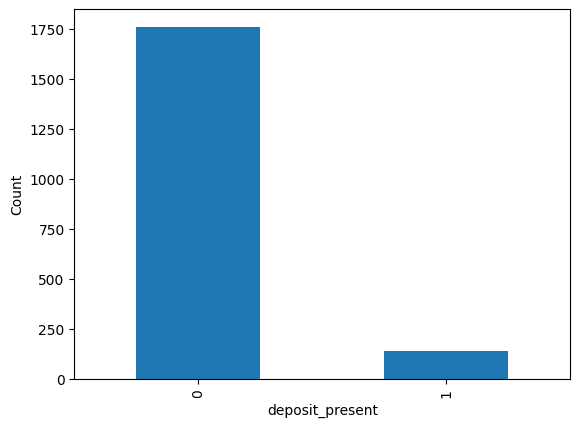

In [7]:
import matplotlib.pyplot as plt

df.deposit_present.value_counts().plot.bar()

plt.ylabel("Count")
plt.show()

In [6]:
missing = df.isna().sum()

missing[missing > 0]

Series([], dtype: int64)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1899.0,4.967361e+03,1.987687e+03,1.700000e+01,3.509500e+03,5.586000e+03,6.459500e+03,8.500000e+03
litho_contact_litho_class,1899.0,9.485519e+00,6.567167e+00,4.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01,2.000000e+01
distance_to_lithology_contact,1899.0,1.407913e+04,1.438084e+04,0.000000e+00,1.919123e+03,9.564394e+03,2.158633e+04,6.985767e+04
deposit_present,1899.0,7.319642e-02,2.605272e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
bouguer,1899.0,-1.719671e+01,1.394255e+01,-5.508000e+01,-2.596500e+01,-1.755000e+01,-8.175000e+00,1.744000e+01
isostatic,1899.0,-7.754676e+00,1.502540e+01,-4.506000e+01,-1.763000e+01,-8.590000e+00,1.700000e+00,3.120000e+01
centroid_x,1899.0,5.365854e+05,1.013216e+05,2.826748e+05,4.629012e+05,5.678573e+05,6.125938e+05,7.154648e+05
centroid_y,1899.0,8.661860e+06,1.379015e+05,8.380251e+06,8.539906e+06,8.694391e+06,8.785657e+06,8.859512e+06
emag,1899.0,-1.467568e+38,1.685709e+38,-3.402823e+38,-3.402823e+38,-4.906081e+01,-7.574942e+00,1.058396e+02
distance_to_fault,1899.0,2.321006e+04,2.506860e+04,1.340049e+00,3.120751e+03,1.455617e+04,3.517674e+04,1.127508e+05


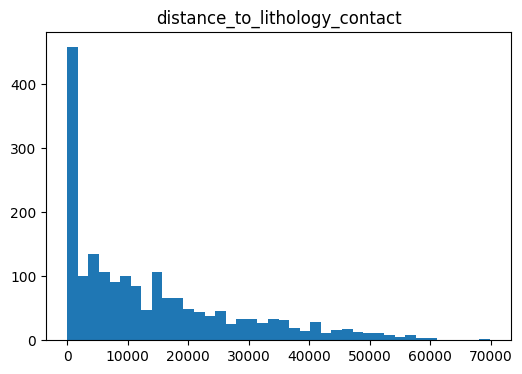

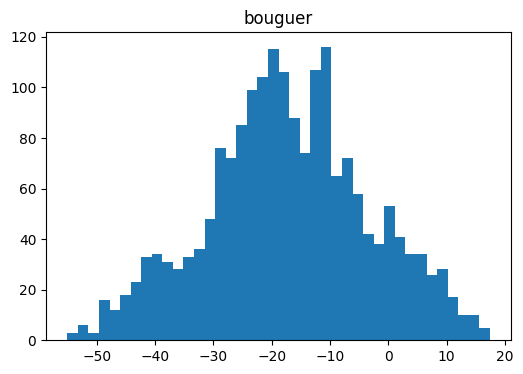

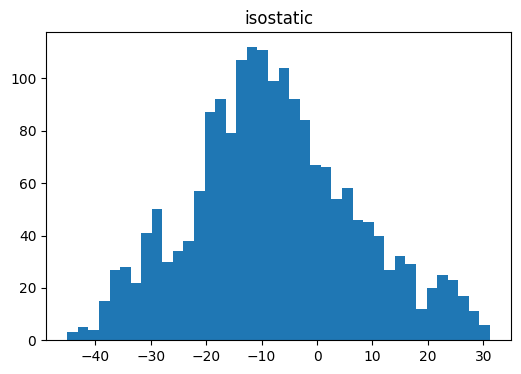

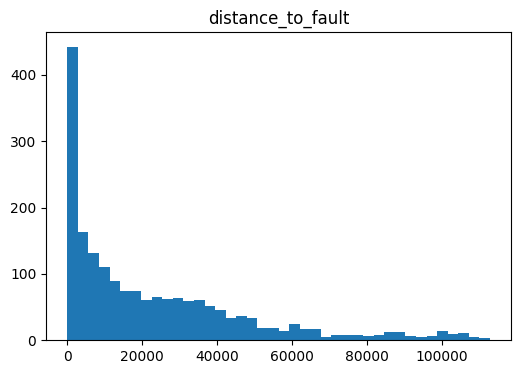

In [8]:
continuous = [
    "distance_to_lithology_contact",
    "bouguer",
    "isostatic",
    "distance_to_fault"
]
for col in continuous:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=40)

    plt.title(col)

    plt.show()

<Figure size 600x400 with 0 Axes>

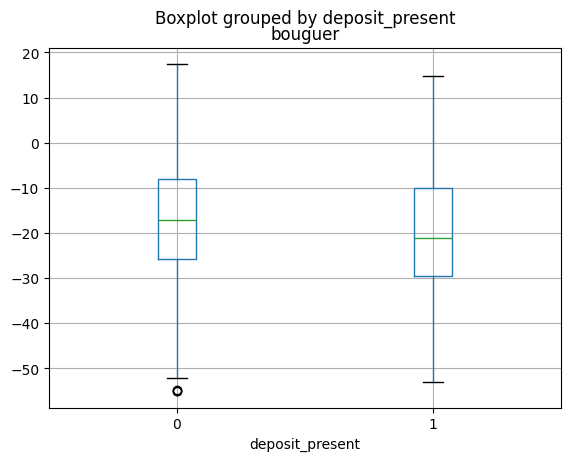

In [9]:
plt.figure(figsize=(6,4))

df.boxplot(
    column="bouguer",
    by="deposit_present"
)

plt.show()

In [10]:
pd.crosstab(
    df.litho_contact_litho_class,
    df.deposit_present
)

deposit_present,0,1
litho_contact_litho_class,,
4,821,70
6,79,6
7,225,14
14,83,0
16,215,14
20,337,35


In [9]:
numeric = [
    "distance_to_lithology_contact",
    "bouguer",
    "isostatic",
    "distance_to_fault"
]

corr = df[numeric].corr()

corr

,distance_to_lithology_contact,bouguer,isostatic,distance_to_fault
distance_to_lithology_contact,1.000000,0.246085,0.320883,-0.206524
bouguer,0.246085,1.000000,0.892456,0.083810
isostatic,0.320883,0.892456,1.000000,-0.210181
distance_to_fault,-0.206524,0.083810,-0.210181,1.000000


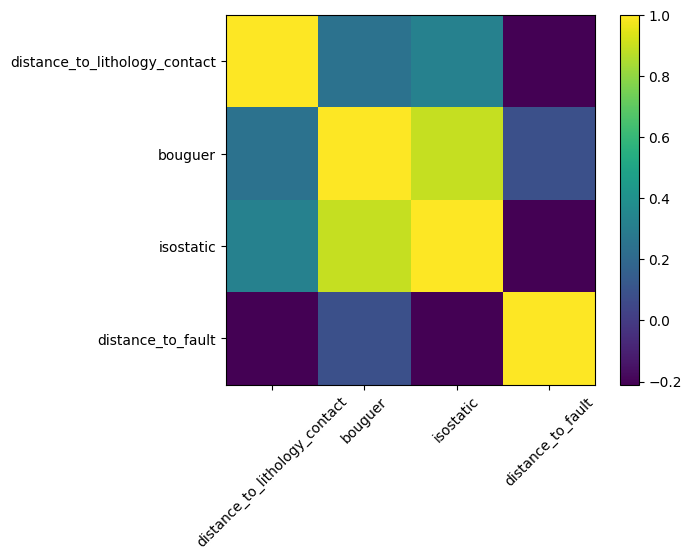

In [10]:
plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.show()